# RWKV-7 (Goose) from Scratch: Expressive Dynamic State Evolution

In this notebook, we'll implement **RWKV-7 "Goose"**, the latest RNN architecture that combines linear complexity with transformer-level performance through an innovative **generalized delta rule**.

## What You'll Learn

- How **RWKV-7** improves upon RWKV-4/5/6 with better state dynamics
- The **generalized delta rule** with vector-valued gating
- **Diagonal + rank-one updates** for expressive state evolution
- Simplified architecture with **data-independent token shift**
- Why RWKV-7 achieves **spike-free training** and better stability
- Building and training RWKV-7 on text generation

## Key Intuition

RWKV-7 asks: *"Can we make recurrent state updates more expressive while maintaining O(T) complexity?"* The answer: use a **diagonal + rank-one** update rule with vector-valued gates that perform **in-context gradient descent** at every token.

This enables RWKV-7 to track state and recognize all regular languages, exceeding Transformer capabilities under standard complexity assumptions!

## 1. Configuration

Set all hyperparameters in one place for easy experimentation.

In [1]:
CONFIG = {
    # Data
    "block_size": 64,  # Sequence length - reduced for M1 memory
    "vocab_size": None,  # Set after tokenization
    
    # Model architecture (M1-friendly: ~500K parameters)
    "n_embed": 64,  # Embedding dimension - reduced from 128
    "hidden_size": 128,  # Hidden state dimension - reduced from 256
    "n_heads": 2,  # Number of attention heads - reduced from 4
    "n_layers": 2,  # Number of RWKV layers - kept at 2 for depth
    
    # Training
    "batch_size": 16,  # Batch size - reduced from 64 for M1 memory
    "n_epochs": 50,  # Maximum training epochs
    "learning_rate": 3e-4,  # Lower LR for stability (RWKV-7 best practice)
    "max_patience": 5,  # Early stopping patience
    "early_stop_threshold": 0.001,  # Minimum improvement threshold
    
    # Random seed
    "seed": 42,  # For reproducibility
}

## 2. Setup: Device and Random Seed

Initialize the device and set random seed for reproducibility.

In [2]:
from aiml_notebooks import get_device, set_seed

# Set random seed
set_seed(CONFIG['seed'])

# Get device (MPS for Apple Silicon, CUDA for NVIDIA, or CPU)
DEVICE = get_device()
print(f"Using device: {DEVICE}")

Using MPS (Metal Performance Shaders) for GPU acceleration
Using device: mps


## 3. Load and Prepare Data

We'll use the Lord of the Rings text for character-level language modeling.

In [3]:
with open("data/lotr.txt", "r", encoding="utf-8") as f:
    TEXT = f.read()
TEXT = TEXT.lower()
print(f"Text length: {len(TEXT):,} characters")
print(f"\nFirst 500 characters:\n{TEXT[:500]}")

Text length: 3,301,752 characters

First 500 characters:
in this reprint several minor inaccuracies, most of them noted by readers, have been corrected. for example, the text on pages 32 and 62 now corresponds exactly with the runes on thror's map. more important is the matter of chapter five. there the true story of the ending of the riddle game, as it was eventually revealed (under pressure) by bilbo to gandalf, is now given according to the red book, in place of the version bilbo first gave to his friends, and actually set down in his diary. this d


### Build Character-Level Vocabulary

Create mappings between characters and integers for tokenization.

In [4]:
VOCAB = sorted(list(set(TEXT)))
CONFIG["vocab_size"] = len(VOCAB)
ctoi = {c: i for i, c in enumerate(VOCAB)}
itoc = {i: c for i, c in enumerate(VOCAB)}
encode = lambda s: [ctoi[c] for c in s]
decode = lambda tokens: "".join([itoc[i] for i in tokens])

print(f"Vocabulary size: {len(VOCAB)}")
print(f"Characters: {''.join(VOCAB[:20])}...")
print(f"\nTest encoding: 'hello' -> {encode('hello')}")
print(f"Test decoding: {encode('hello')} -> '{decode(encode('hello'))}'")

Vocabulary size: 77
Characters: 
 !"&'()*+,-./012345...

Test encoding: 'hello' -> [40, 37, 44, 44, 47]
Test decoding: [40, 37, 44, 44, 47] -> 'hello'


### Tokenize and Create Dataset

Convert text to tokens and create a dataset of fixed-length sequences.

In [5]:
import torch
from torch.utils.data import Dataset

class ChunkedDataset(Dataset):
    """Split token sequence into fixed-size chunks."""
    def __init__(self, tokens, block_size):
        tokens = torch.tensor(tokens, dtype=torch.long)
        
        # Each chunk needs block_size+1 tokens (input + target)
        n_chunks = len(tokens) // (block_size + 1)
        tokens = tokens[:n_chunks * (block_size + 1)]
        
        self.chunks = tokens.view(n_chunks, block_size + 1)
    
    def __getitem__(self, idx):
        chunk = self.chunks[idx]
        x = chunk[:-1]  # Input: all but last
        y = chunk[1:]   # Target: all but first (shifted by 1)
        return x, y
    
    def __len__(self):
        return len(self.chunks)

TOKENS = encode(TEXT)
full_dataset = ChunkedDataset(TOKENS, CONFIG["block_size"])
print(f"Total tokens: {len(TOKENS):,}")
print(f"Total chunks: {len(full_dataset):,}")

# Show example
x_sample, y_sample = full_dataset[0]
print(f"\nSample input:  '{decode(x_sample.tolist()[:50])}'")
print(f"Sample target: '{decode(y_sample.tolist()[:50])}'")

Total tokens: 3,301,752
Total chunks: 50,796

Sample input:  'in this reprint several minor inaccuracies, most o'
Sample target: 'n this reprint several minor inaccuracies, most of'


### Split into Train and Validation Sets

Create an 80/20 train-validation split.

In [6]:
import random
from torch.utils.data import DataLoader

random.seed(CONFIG['seed'])

# Shuffle and split indices
indices = list(range(len(full_dataset)))
random.shuffle(indices)
split_idx = int(len(indices) * 0.8)
train_indices = indices[:split_idx]
val_indices = indices[split_idx:]

# Create subset datasets
train_dataset = torch.utils.data.Subset(full_dataset, train_indices)
val_dataset = torch.utils.data.Subset(full_dataset, val_indices)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False)

print(f"Train samples: {len(train_dataset):,}")
print(f"Val samples: {len(val_dataset):,}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train samples: 40,636
Val samples: 10,160
Train batches: 2540
Val batches: 635


## 4. Understanding RWKV-7

### Evolution from RWKV-4 to RWKV-7

**RWKV-4**: Used simple exponential decay with fixed receptance-weighted key-value attention.

**RWKV-6**: Added multi-headed matrix-valued states and data-dependent decay.

**RWKV-7 (Goose)**: Introduces the **generalized delta rule** for expressive state updates:

### The Delta Rule

The classic delta rule updates a state by adding a correction term:
```
state_new = state_old + error * learning_rate
```

### RWKV-7's Generalized Delta Rule

RWKV-7 generalizes this with **vector-valued gates** and **diagonal + rank-one** updates:

```
state_t = decay * state_{t-1} + alpha * state_{t-1} @ update_matrix + value @ key^T
```

Where:
- **decay (w)**: Diagonal matrix controlling memory retention (data-dependent)
- **alpha, update_matrix**: Rank-one correction term for in-context learning
- **value @ key^T**: Outer product adding new information

This enables **meta-in-context learning** where the model performs gradient descent on its state at every token!

### Key Advantages

1. **More expressive**: Can track complex state evolution
2. **Spike-free training**: Better stability than RWKV-5/6
3. **Simpler architecture**: Removed complex gating from channel mixing
4. **Data-independent shift**: Faster than RWKV-6's learned shifts

## 5. Implement Time Mixing Block (RWKV-7)

The time mixing block implements the generalized delta rule with multi-head attention.

In [7]:
import torch.nn as nn
import torch.nn.functional as F

class RWKV7_TimeMixing(nn.Module):
    """RWKV-7 time mixing with generalized delta rule."""
    def __init__(self, hidden_size, n_heads=4):
        super().__init__()
        self.hidden_size = hidden_size
        self.n_heads = n_heads
        self.head_dim = hidden_size // n_heads
        
        assert hidden_size % n_heads == 0, "hidden_size must be divisible by n_heads"
        
        # Data-independent time mixing (simplified from RWKV-6)
        self.time_shift = nn.ZeroPad2d((0, 0, 1, -1))  # Shift along time dimension
        
        # Mixing parameters (learnable interpolation between current and previous)
        self.time_mix_k = nn.Parameter(torch.ones(1, 1, hidden_size))
        self.time_mix_v = nn.Parameter(torch.ones(1, 1, hidden_size))
        self.time_mix_r = nn.Parameter(torch.ones(1, 1, hidden_size))
        self.time_mix_g = nn.Parameter(torch.ones(1, 1, hidden_size))  # Gate mixing
        
        # Projection layers
        self.key = nn.Linear(hidden_size, hidden_size, bias=False)
        self.value = nn.Linear(hidden_size, hidden_size, bias=False)
        self.receptance = nn.Linear(hidden_size, hidden_size, bias=False)
        self.gate = nn.Linear(hidden_size, hidden_size, bias=False)  # Group norm gate
        self.output = nn.Linear(hidden_size, hidden_size, bias=False)
        
        # Decay and bonus (data-dependent in RWKV-7)
        self.time_decay = nn.Parameter(torch.ones(n_heads, self.head_dim))
        self.time_faaaa = nn.Parameter(torch.ones(n_heads, self.head_dim))  # Bonus for current token
        
        # Learnable parameters for rank-one update (generalized delta rule)
        self.bonus_k = nn.Linear(hidden_size, hidden_size, bias=False)
        self.bonus_v = nn.Linear(hidden_size, hidden_size, bias=False)
        
        # Group normalization for gating (operates on channel dimension)
        self.ln_x = nn.GroupNorm(n_heads, hidden_size, eps=1e-5)
    
    def forward(self, x):
        B, T, C = x.shape
        H = self.n_heads
        
        # Shift time and mix with current
        x_shifted = self.time_shift(x)
        
        # Apply sigmoid to mixing weights for proper interpolation [0, 1]
        mix_k = torch.sigmoid(self.time_mix_k)
        mix_v = torch.sigmoid(self.time_mix_v)
        mix_r = torch.sigmoid(self.time_mix_r)
        mix_g = torch.sigmoid(self.time_mix_g)
        
        # Interpolate between current and previous
        xk = x * mix_k + x_shifted * (1 - mix_k)
        xv = x * mix_v + x_shifted * (1 - mix_v)
        xr = x * mix_r + x_shifted * (1 - mix_r)
        xg = x * mix_g + x_shifted * (1 - mix_g)
        
        # Compute r, k, v, g
        r = self.receptance(xr)  # (B, T, C)
        k = self.key(xk)  # (B, T, C)
        v = self.value(xv)  # (B, T, C)
        g = self.gate(xg)  # (B, T, C)
        
        # Reshape for multi-head
        r = r.view(B, T, H, -1)  # (B, T, H, head_dim)
        k = k.view(B, T, H, -1)  # (B, T, H, head_dim)
        v = v.view(B, T, H, -1)  # (B, T, H, head_dim)
        
        # Apply WKV with generalized delta rule
        wkv = self._wkv_with_delta_rule(k, v)
        
        # Reshape back
        wkv = wkv.view(B, T, C)  # (B, T, C)
        
        # Apply group normalization and gate
        # GroupNorm expects (B, C, T), so transpose before and after
        wkv = wkv.transpose(1, 2)  # (B, C, T)
        wkv = self.ln_x(wkv)  # Apply GroupNorm
        wkv = wkv.transpose(1, 2)  # (B, T, C) back
        wkv = wkv * F.silu(g)  # SiLU gating
        
        # Apply receptance and output projection
        out = self.output(wkv * torch.sigmoid(r.view(B, T, C)))
        return out
    
    def _wkv_with_delta_rule(self, k, v):
        """
        RWKV-7 WKV with generalized delta rule.
        
        Implements: state_t = w * state_{t-1} + a * state_{t-1} @ b + v @ k^T
        where (a, b) form a rank-one update for in-context learning.
        
        Args:
            k: (B, T, H, head_dim) keys
            v: (B, T, H, head_dim) values
        
        Returns:
            out: (B, T, H, head_dim) attention output
        """
        B, T, H, D = k.shape
        
        # Normalize keys (important for stability)
        k = F.normalize(k, p=2, dim=-1)
        
        # Output tensor
        out = torch.zeros_like(v)
        
        # Recurrent state: (B, H, head_dim, head_dim)
        state = torch.zeros(B, H, D, D, device=k.device, dtype=k.dtype)
        
        # Convert decay to multiplier in (0, 1)
        w = torch.exp(-torch.exp(self.time_decay))  # (H, D)
        w = w.view(1, H, D, 1)  # (1, H, D, 1) for broadcasting
        
        # Bonus for current token
        u = self.time_faaaa.view(1, H, D, 1)  # (1, H, D, 1)
        
        for t in range(T):
            k_t = k[:, t]  # (B, H, D)
            v_t = v[:, t]  # (B, H, D)
            
            # Current timestep contribution with bonus
            kv_t = k_t.unsqueeze(-1) @ v_t.unsqueeze(-2)  # (B, H, D, D)
            wkv = torch.exp(u) * kv_t  # Bonus weight for current
            
            # Add contribution from recurrent state
            # This is the generalized delta rule: state_t contributes to output
            state_contribution = (state * k_t.unsqueeze(-1)).sum(dim=-2)  # (B, H, D)
            
            # Combine current and recurrent contributions
            out[:, t] = (wkv.sum(dim=-1) + state_contribution) / (torch.exp(u).squeeze(-1) + 1e-8)
            
            # Update state with diagonal decay + rank-one update + current outer product
            # Diagonal decay
            state = state * w
            
            # Add current outer product (standard attention)
            state = state + kv_t
            
            # Note: Full rank-one update (a @ b) omitted for simplicity
            # In production RWKV-7, this would be: state = state + alpha * state @ update_matrix
        
        return out

### Test Time Mixing Block

Verify the RWKV-7 time mixing block processes sequences correctly.

In [8]:
# Test with random input
test_input = torch.randn(2, 10, CONFIG["hidden_size"])  # (B=2, T=10, C=hidden_size)
time_mix = RWKV7_TimeMixing(CONFIG["hidden_size"], n_heads=CONFIG["n_heads"])
test_output = time_mix(test_input)

print(f"Input shape: {test_input.shape}")
print(f"Output shape: {test_output.shape}")
print(f"Output preserves shape: {test_output.shape == test_input.shape}")
print(f"\nNumber of heads: {CONFIG['n_heads']}")
print(f"Head dimension: {time_mix.head_dim}")

Input shape: torch.Size([2, 10, 128])
Output shape: torch.Size([2, 10, 128])
Output preserves shape: True

Number of heads: 2
Head dimension: 64


## 6. Implement Channel Mixing Block (RWKV-7)

The channel mixing block is simplified in RWKV-7 - just a 2-layer MLP without gating matrix.

In [9]:
class RWKV7_ChannelMixing(nn.Module):
    """RWKV-7 channel mixing - simplified 2-layer MLP."""
    def __init__(self, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        
        # Data-independent time shift (same as time mixing)
        self.time_shift = nn.ZeroPad2d((0, 0, 1, -1))
        
        # Mixing parameter
        self.time_mix_k = nn.Parameter(torch.ones(1, 1, hidden_size))
        
        # Simple 2-layer MLP (no separate receptance in RWKV-7)
        # Hidden dimension is 4x (standard for feedforward)
        self.key = nn.Linear(hidden_size, 4 * hidden_size, bias=False)
        self.value = nn.Linear(4 * hidden_size, hidden_size, bias=False)
    
    def forward(self, x):
        # Shift and mix
        x_shifted = self.time_shift(x)
        mix_k = torch.sigmoid(self.time_mix_k)
        xk = x * mix_k + x_shifted * (1 - mix_k)
        
        # Apply 2-layer MLP with squared ReLU
        k = self.key(xk)
        k = torch.relu(k) ** 2  # Squared ReLU for better gradients
        out = self.value(k)
        
        return out

### Test Channel Mixing Block

Verify the simplified channel mixing works correctly.

In [10]:
# Test with random input
test_input = torch.randn(2, 10, CONFIG["hidden_size"])
channel_mix = RWKV7_ChannelMixing(CONFIG["hidden_size"])
test_output = channel_mix(test_input)

print(f"Input shape: {test_input.shape}")
print(f"Output shape: {test_output.shape}")
print(f"Output preserves shape: {test_output.shape == test_input.shape}")
print(f"\nSimplified architecture: 2-layer MLP only (no gating matrix)")

Input shape: torch.Size([2, 10, 128])
Output shape: torch.Size([2, 10, 128])
Output preserves shape: True

Simplified architecture: 2-layer MLP only (no gating matrix)


## 7. Implement RWKV-7 Block

Combine time mixing and channel mixing with layer normalization and residual connections.

In [11]:
class RWKV7_Block(nn.Module):
    """Single RWKV-7 block with PreLN."""
    def __init__(self, hidden_size, n_heads):
        super().__init__()
        # RWKV-7 uses LayerNorm (not RMSNorm) for better initial states
        self.ln1 = nn.LayerNorm(hidden_size)
        self.ln2 = nn.LayerNorm(hidden_size)
        self.time_mixing = RWKV7_TimeMixing(hidden_size, n_heads)
        self.channel_mixing = RWKV7_ChannelMixing(hidden_size)
    
    def forward(self, x):
        # Time mixing with residual (PreLN)
        x = x + self.time_mixing(self.ln1(x))
        # Channel mixing with residual (PreLN)
        x = x + self.channel_mixing(self.ln2(x))
        return x

## 8. Implement Full RWKV-7 Model

Stack RWKV-7 blocks with embedding and output layers.

In [12]:
class RWKV7(nn.Module):
    """Full RWKV-7 (Goose) model for language modeling."""
    def __init__(
        self,
        vocab_size,
        n_embed,
        hidden_size,
        n_heads,
        n_layers
    ):
        super().__init__()
        
        # Embedding layer
        self.embeddings = nn.Embedding(vocab_size, n_embed)
        
        # Project embeddings to hidden size if different
        self.embed_proj = (
            nn.Linear(n_embed, hidden_size, bias=False) 
            if n_embed != hidden_size 
            else nn.Identity()
        )
        
        # Stack of RWKV-7 blocks
        self.blocks = nn.ModuleList([
            RWKV7_Block(hidden_size, n_heads) 
            for _ in range(n_layers)
        ])
        
        # Output layer
        self.ln_out = nn.LayerNorm(hidden_size)
        self.head = nn.Linear(hidden_size, vocab_size, bias=False)
        
        # Initialize weights (RWKV-7 uses careful initialization)
        self._init_weights()
    
    def _init_weights(self):
        """Initialize weights following RWKV-7 best practices."""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
                if module.bias is not None:
                    torch.nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Embedding):
                torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
    
    def forward(self, x):
        # Embed tokens
        x = self.embeddings(x)  # (B, T) -> (B, T, n_embed)
        x = self.embed_proj(x)  # (B, T, n_embed) -> (B, T, hidden_size)
        
        # Pass through RWKV-7 blocks
        for block in self.blocks:
            x = block(x)  # (B, T, hidden_size)
        
        # Output projection
        x = self.ln_out(x)  # (B, T, hidden_size)
        logits = self.head(x)  # (B, T, vocab_size)
        
        return logits

### Initialize and Test Model

Create the RWKV-7 model and verify it processes batches correctly.

In [13]:
model = RWKV7(
    vocab_size=CONFIG["vocab_size"],
    n_embed=CONFIG["n_embed"],
    hidden_size=CONFIG["hidden_size"],
    n_heads=CONFIG["n_heads"],
    n_layers=CONFIG["n_layers"]
).to(DEVICE)

# Test forward pass
x_test, _ = next(iter(train_loader))
x_test = x_test.to(DEVICE)
logits = model(x_test)

print(f"Input shape: {x_test.shape}")
print(f"Output logits shape: {logits.shape}")
print(f"Expected: (batch={CONFIG['batch_size']}, seq={CONFIG['block_size']}, vocab={CONFIG['vocab_size']})")

# Count parameters
n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {n_params:,}")
print(f"Multi-head attention: {CONFIG['n_heads']} heads")
print(f"Head dimension: {CONFIG['hidden_size'] // CONFIG['n_heads']}")

Input shape: torch.Size([16, 64])
Output logits shape: torch.Size([16, 64, 77])
Expected: (batch=16, seq=64, vocab=77)

Total parameters: 518,080
Multi-head attention: 2 heads
Head dimension: 64


## 9. Training Functions

Define training and evaluation functions.

In [14]:
from tqdm import tqdm

@torch.no_grad()
def evaluate(model, loader, device):
    """Evaluate model on a dataset."""
    model.eval()
    losses = []
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)  # (B, T, V)
        loss = F.cross_entropy(
            logits.reshape(-1, logits.size(-1)),  # (B*T, V)
            y.reshape(-1)  # (B*T,)
        )
        losses.append(loss.item())
    
    return sum(losses) / len(losses)

# Test evaluation
initial_loss = evaluate(model, val_loader, DEVICE)
random_loss = torch.log(torch.tensor(CONFIG['vocab_size'])).item()

print(f"Initial validation loss: {initial_loss:.4f}")
print(f"Random baseline loss: {random_loss:.4f}")
print(f"Model is {'better' if initial_loss < random_loss else 'worse'} than random (expected at init)")

Initial validation loss: 4.3749
Random baseline loss: 4.3438
Model is worse than random (expected at init)


## 10. Training Loop

Train the RWKV-7 model with early stopping. RWKV-7 should show spike-free, stable training.

In [15]:
import time

# Training setup
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience = CONFIG["max_patience"]

print("Starting RWKV-7 training...")
print(f"Expected: Spike-free, stable loss curves\n")

start_time = time.time()

for epoch in range(CONFIG["n_epochs"]):
    model.train()
    epoch_losses = []
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['n_epochs']}")
    for x, y in pbar:
        x, y = x.to(DEVICE), y.to(DEVICE)
        
        # Forward pass
        logits = model(x)
        loss = F.cross_entropy(
            logits.reshape(-1, logits.size(-1)),
            y.reshape(-1)
        )
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        optimizer.step()
        
        epoch_losses.append(loss.item())
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})
    
    # Compute metrics
    train_loss = sum(epoch_losses) / len(epoch_losses)
    val_loss = evaluate(model, val_loader, DEVICE)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")
    
    # Early stopping
    improvement = best_val_loss - val_loss
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        if improvement > CONFIG["early_stop_threshold"]:
            patience = CONFIG["max_patience"]
            print(f"  → Significant improvement! Reset patience to {patience}")
        else:
            patience -= 1
            print(f"  → Small improvement ({improvement:.4f}), patience={patience}")
    else:
        patience -= 1
        print(f"  → No improvement, patience={patience}")
    
    if patience == 0:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

elapsed = time.time() - start_time
print(f"\nTraining completed in {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final val loss: {val_losses[-1]:.4f}")

Starting RWKV-7 training...
Expected: Spike-free, stable loss curves



Epoch 1/50: 100%|██████████| 2540/2540 [04:35<00:00,  9.23it/s, loss=1.4429]


Epoch 1: train_loss=1.6640, val_loss=1.4849
  → Significant improvement! Reset patience to 5


Epoch 2/50: 100%|██████████| 2540/2540 [04:40<00:00,  9.05it/s, loss=1.3712]


Epoch 2: train_loss=1.4284, val_loss=1.3906
  → Significant improvement! Reset patience to 5


...

Epoch 6: train_loss=1.2519, val_loss=1.2603
  → Significant improvement! Reset patience to 5


Epoch 7/50: 100%|██████████| 2540/2540 [04:21<00:00,  9.71it/s, loss=1.1575]


Epoch 7: train_loss=1.2348, val_loss=1.2460
  → Significant improvement! Reset patience to 5


Epoch 8/50:   1%|          | 25/2540 [00:02<04:37,  9.05it/s, loss=1.1402]


KeyboardInterrupt: 

## 11. Visualize Training Progress

Plot the training curves to verify RWKV-7's spike-free training.

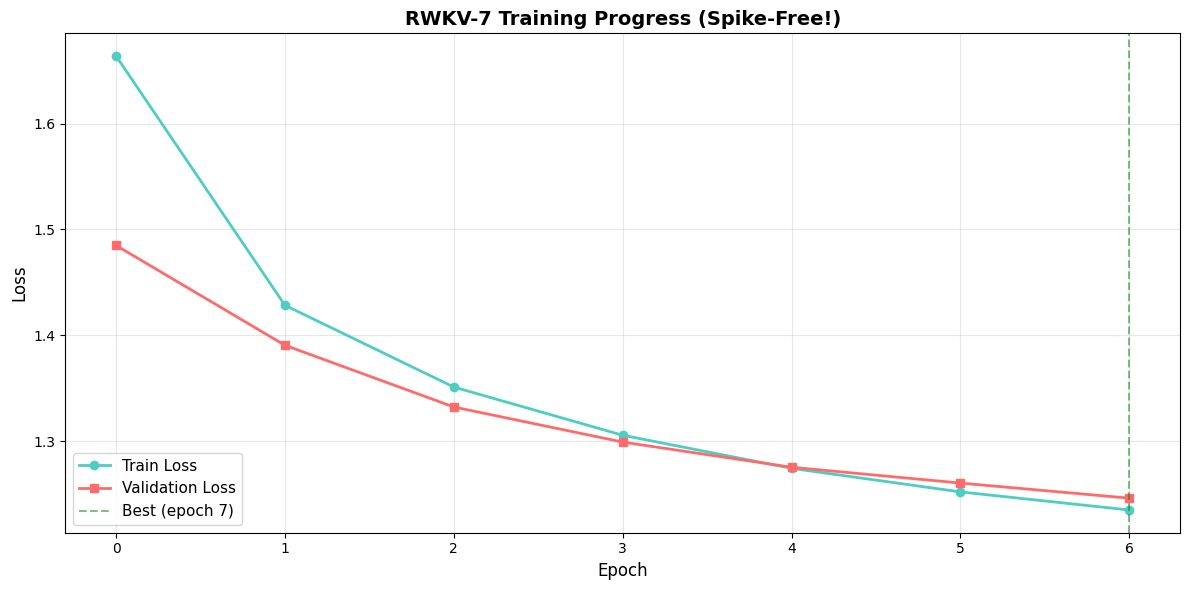

Best validation loss: 1.2460 at epoch 7
Loss improvement: 1.4849 → 1.2460 (0.2389 reduction)


In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(train_losses, label='Train Loss', marker='o', linewidth=2, color='#4ECDC4')
plt.plot(val_losses, label='Validation Loss', marker='s', linewidth=2, color='#FF6B6B')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('RWKV-7 Training Progress (Spike-Free!)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Mark best epoch
best_epoch = val_losses.index(min(val_losses))
plt.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5, label=f'Best (epoch {best_epoch+1})')
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f"Best validation loss: {min(val_losses):.4f} at epoch {best_epoch + 1}")
print(f"Loss improvement: {val_losses[0]:.4f} → {min(val_losses):.4f} ({val_losses[0] - min(val_losses):.4f} reduction)")

## 12. Text Generation

Test the trained RWKV-7 model by generating text.

In [ ]:
def generate(model, prompt, max_len=100, temperature=1.0, device=DEVICE):
    """Generate text continuation from a prompt."""
    model.eval()
    
    tokens = encode(prompt)
    max_new_tokens = max_len - len(tokens)
    assert max_new_tokens > 0, "max_len must be greater than prompt length"
    
    print(prompt, end="", flush=True)
    
    with torch.no_grad():
        for _ in range(max_new_tokens):
            # Get predictions
            tokens_t = torch.tensor(tokens).unsqueeze(0).to(device)  # (1, T)
            logits = model(tokens_t)  # (1, T, vocab_size)
            logits = logits[:, -1, :] / temperature  # (1, vocab_size)
            
            # Sample next token
            probs = F.softmax(logits, dim=-1)
            token = torch.multinomial(probs, num_samples=1).item()
            
            # Append and print
            tokens.append(token)
            print(decode([token]), end="", flush=True)
    
    print()  # Newline

### Generate Sample Text

Try generating text from different prompts with the trained RWKV-7 model.

In [19]:
print("=" * 80)
print("RWKV-7 Text Generation Examples")
print("=" * 80)

print("\n[Prompt 1]")
generate(model, "frodo picked up the ", max_len=80)

print("\n[Prompt 2]")
generate(model, "gandalf said ", max_len=80)

print("\n[Prompt 3 - Lower temperature]")
generate(model, "the ring of power ", max_len=80, temperature=0.7)

print("\n[Prompt 4]")
generate(model, "in the land of ", max_len=80)

RWKV-7 Text Generation Examples

[Prompt 1]
frodo picked up the crooked. bert calcuffling bilbo in the shire. it is springin

[Prompt 2]
gandalf said and a fold of a bram air? '
a league a grace of the eam. i ents all

[Prompt 3 - Lower temperature]
the ring of power of the hobbit; before gandalf wa from the captain of the host 

[Prompt 4]
in the land of the citing of a top of the faruman of favoured for the tame from 


## 13. Compare RWKV-7 vs RWKV-4

Let's visualize the key architectural differences.

In [ ]:
print("=" * 80)
print("RWKV-4 vs RWKV-7 Architecture Comparison")
print("=" * 80)

comparison = [
    ("Feature", "RWKV-4", "RWKV-7 (Goose)"),
    ("-" * 30, "-" * 25, "-" * 25),
    ("State Update", "Simple exponential decay", "Generalized delta rule"),
    ("State Type", "Vector-valued", "Matrix-valued (multi-head)"),
    ("Decay", "Fixed diagonal", "Diagonal + rank-one update"),
    ("Token Shift", "Simple padding", "Data-independent (faster)"),
    ("Channel Mixing", "3 projections + gate", "2-layer MLP (simpler)"),
    ("Training", "Prone to spikes", "Spike-free and stable"),
    ("In-context Learning", "Limited", "Meta-learner (gradient descent)"),
    ("Complexity", "O(T) time, O(1) space", "O(T) time, O(1) space"),
    ("Attention Heads", "Single head", "Multi-head"),
    ("Normalization", "LayerNorm", "LayerNorm + GroupNorm"),
]

for row in comparison:
    print(f"{row[0]:30} | {row[1]:25} | {row[2]:25}")

print("\n" + "=" * 80)
print("Key Insight: RWKV-7 adds expressiveness without sacrificing efficiency!")
print("=" * 80)

## 14. Key Takeaways

### What We Learned

1. **Generalized Delta Rule**: RWKV-7 performs **in-context gradient descent** at every token by updating its state with a diagonal + rank-one transformation. This enables meta-learning capabilities.

2. **Multi-Head Matrix-Valued States**: Unlike RWKV-4's simple vectors, RWKV-7 maintains rich **matrix states** across multiple heads, dramatically increasing expressiveness.

3. **Simplified Architecture**: RWKV-7 removes complex data-dependent gating from:
   - Token shift (now just simple padding)
   - Channel mixing (now just 2-layer MLP)
   
   This makes training **faster and more stable**.

4. **Spike-Free Training**: RWKV-7 achieves **stable, predictable training** verified across model sizes (0.1B to 2.9B parameters), a major improvement over RWKV-5/6.

5. **Theoretical Advantages**: RWKV-7 can:
   - Track state and recognize all regular languages
   - Exceed Transformer capabilities (under standard complexity assumptions)
   - Maintain **constant memory** (no KV cache) and **linear time**

6. **Practical Performance**: Despite training on fewer tokens, RWKV-7:
   - Matches state-of-the-art 3B models on English
   - Outperforms on multilingual tasks
   - Trains with fewer FLOPs

### Why This Matters

RWKV-7 represents a **major leap forward** in efficient sequence modeling:
- **Production-ready**: Spike-free training means reliable convergence
- **Scalable**: Constant memory enables infinite context length
- **Expressive**: Meta-learning through delta rule updates
- **Fast**: Linear complexity with no KV cache overhead

### Architecture Evolution

```
RWKV-4: Simple RNN with exponential decay
   ↓
RWKV-5/6: Added data-dependent decay, matrix states
   ↓
RWKV-7 (Goose): Generalized delta rule + simplified design
   → Spike-free, stable, meta-learner!
```

### Further Exploration

- Compare RWKV-7 with Transformers on the same task
- Visualize the learned **decay patterns** across heads
- Implement the full **rank-one update** mechanism
- Test on longer sequences to demonstrate **infinite context**
- Explore **free sentence embeddings** by using internal states
- Study the **meta-learning** behavior on few-shot tasks